# Two-Hand Static Phrase Recognition
Based on the single-hand letter model. Captures **both hands** per frame as a single 128-feature vector (left hand 63 + handedness + right hand 63 + handedness). Missing hands are zero-padded to keep input size fixed.

In [ ]:
!pip install opencv-python mediapipe==0.10.14 matplotlib seaborn tensorflow scikit-learn tensorflowjs ipywidgets

In [1]:
import cv2
import mediapipe as mp
import numpy as np
import os
from time import time


2026-03-15 14:57:54.149183: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-15 14:57:54.155254: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-15 14:57:54.176903: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773557874.209029   85437 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773557874.219380   85437 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773557874.242318   85437 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

# Data Collection

Each sample captures **both hands** in a single 128-dim vector:
- Left hand: 21 landmarks × 3 (xyz) = 63 values + 1 handedness = 64
- Right hand: 21 landmarks × 3 (xyz) = 63 values + 1 handedness = 64
- If a hand is missing → padded with zeros

Press `c` to capture a frame, `q` to quit early.

In [2]:
PHRASE_CLASSES = [
    "Thank You", "I Love You", "Please", "Sorry", "Help",
    "Yes", "No", "Good", "Bad", "More",
    "Finished", "Eat", "Drink", "Home", "Friend",
    "Unknown"
]
DATA_PATH          = "phrase_dataset"
SAMPLES_PER_PHRASE = 200
CENTER_BY_WRIST    = True
COUNTDOWN_SECONDS  = 3      # seconds to wait after pressing space before capture

os.makedirs(DATA_PATH, exist_ok=True)
for p in PHRASE_CLASSES:
    os.makedirs(os.path.join(DATA_PATH, p), exist_ok=True)

mp_hands = mp.solutions.hands
mp_draw  = mp.solutions.drawing_utils
hands    = mp_hands.Hands(
    static_image_mode=False,
    max_num_hands=2,
    min_detection_confidence=0.7,
    min_tracking_confidence=0.7
)

def extract_two_hand_keypoints(result):
    left_pts  = np.zeros(64)
    right_pts = np.zeros(64)
    if result.multi_hand_landmarks:
        for lm, hd in zip(result.multi_hand_landmarks, result.multi_handedness):
            label    = hd.classification[0].label
            pts      = np.array([[p.x, p.y, p.z] for p in lm.landmark])
            if CENTER_BY_WRIST:
                pts -= pts[0]
            pts_flat = np.append(pts.flatten(), 0 if label == "Left" else 1)
            if label == "Left":
                left_pts  = pts_flat
            else:
                right_pts = pts_flat
    return np.concatenate([left_pts, right_pts])

cap         = cv2.VideoCapture(0)
countdown_start = None   # time when space was pressed, None = not counting down

for phrase in PHRASE_CLASSES:
    print(f"\nCollecting: {phrase}  ({SAMPLES_PER_PHRASE} samples)")
    print("Get into pose → press [SPACE] → hold for 3 seconds → auto-capture")
    print("Press [q] to skip to next phrase.")
    count = 0

    while count < SAMPLES_PER_PHRASE:
        ret, frame = cap.read()
        if not ret:
            continue

        frame  = cv2.flip(frame, 1)
        rgb    = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        result = hands.process(rgb)

        if result.multi_hand_landmarks:
            for lm in result.multi_hand_landmarks:
                mp_draw.draw_landmarks(frame, lm, mp_hands.HAND_CONNECTIONS)

        hands_found = len(result.multi_hand_landmarks) if result.multi_hand_landmarks else 0
        now         = time()

        # ── Countdown logic ───────────────────────────────────────────────────
        if countdown_start is not None:
            elapsed   = now - countdown_start
            remaining = COUNTDOWN_SECONDS - elapsed

            if remaining > 0:
                # Show big countdown number
                cv2.putText(frame, str(int(remaining) + 1),
                            (frame.shape[1]//2 - 40, frame.shape[0]//2 + 40),
                            cv2.FONT_HERSHEY_SIMPLEX, 5, (0, 0, 255), 8)
                cv2.putText(frame, "HOLD YOUR POSE!",
                            (frame.shape[1]//2 - 150, frame.shape[0]//2 - 80),
                            cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 255), 2)
            else:
                # Countdown done — capture
                keypoints = extract_two_hand_keypoints(result)
                np.save(os.path.join(DATA_PATH, phrase, f"{count:03d}.npy"), keypoints)
                count          += 1
                countdown_start = None
                print(f"  Captured {count}/{SAMPLES_PER_PHRASE}")

                # Flash green to confirm capture
                flash = frame.copy()
                cv2.rectangle(flash, (0,0), (frame.shape[1], frame.shape[0]), (0,255,0), 20)
                cv2.addWeighted(flash, 0.4, frame, 0.6, 0, frame)

        # ── HUD ───────────────────────────────────────────────────────────────
        cv2.putText(frame, f"{phrase}  {count}/{SAMPLES_PER_PHRASE}",
                    (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,255,0), 2)
        cv2.putText(frame, f"Hands: {hands_found}",
                    (10, 60), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,0), 2)

        if countdown_start is None:
            cv2.putText(frame, "[SPACE] Countdown  [c] Instant  [q] Skip",
                        (10, frame.shape[0]-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (180,180,180), 1)

        cv2.imshow("Collect Phrases", frame)

        k = cv2.waitKey(1) & 0xFF
        if k == ord(" ") and countdown_start is None:
            countdown_start = time()   # start 3-second countdown
        if k == ord("c"):
            # instant capture — no countdown
            keypoints = extract_two_hand_keypoints(result)
            np.save(os.path.join(DATA_PATH, phrase, f"{count:03d}.npy"), keypoints)
            count          += 1
            countdown_start = None
            print(f"  Captured {count}/{SAMPLES_PER_PHRASE}")
        if k == ord("q"):
            countdown_start = None
            break

cap.release()
cv2.destroyAllWindows()
print("\nDone collecting!")


I0000 00:00:1773557879.669201   85437 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1773557879.674171   85612 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: Mesa Intel(R) UHD Graphics 620 (WHL GT2)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1773557879.697607   85603 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1773557879.732080   85602 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.



Collecting: Thank You  (200 samples)
Get into pose → press [SPACE] → hold for 3 seconds → auto-capture
Press [q] to skip to next phrase.


QFontDatabase: Cannot find font directory /home/bennybun29/Documents/jupyter_projects/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/bennybun29/Documents/jupyter_projects/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/bennybun29/Documents/jupyter_projects/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/bennybun29/Documents/jupyter_projects/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ fo


Collecting: I Love You  (200 samples)
Get into pose → press [SPACE] → hold for 3 seconds → auto-capture
Press [q] to skip to next phrase.

Collecting: Please  (200 samples)
Get into pose → press [SPACE] → hold for 3 seconds → auto-capture
Press [q] to skip to next phrase.

Collecting: Sorry  (200 samples)
Get into pose → press [SPACE] → hold for 3 seconds → auto-capture
Press [q] to skip to next phrase.

Collecting: Help  (200 samples)
Get into pose → press [SPACE] → hold for 3 seconds → auto-capture
Press [q] to skip to next phrase.

Collecting: Yes  (200 samples)
Get into pose → press [SPACE] → hold for 3 seconds → auto-capture
Press [q] to skip to next phrase.

Collecting: No  (200 samples)
Get into pose → press [SPACE] → hold for 3 seconds → auto-capture
Press [q] to skip to next phrase.

Collecting: Good  (200 samples)
Get into pose → press [SPACE] → hold for 3 seconds → auto-capture
Press [q] to skip to next phrase.

Collecting: Bad  (200 samples)
Get into pose → press [SPACE] →

# Data Splitting and Preprocessing

In [3]:
import os
import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.utils import to_categorical

X, y = [], []
for i, phrase in enumerate(PHRASE_CLASSES):
    folder = os.path.join(DATA_PATH, phrase)
    files  = [f for f in os.listdir(folder) if f.endswith(".npy")]
    for f in files:
        X.append(np.load(os.path.join(folder, f)))
        y.append(i)

X = np.array(X)
y = to_categorical(np.array(y), len(PHRASE_CLASSES))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Input shape : {X.shape[1]} features  (64 left + 64 right)")
print(f"Train       : {X_train.shape}")
print(f"Test        : {X_test.shape}")
print(f"Classes     : {len(PHRASE_CLASSES)}")


Input shape : 128 features  (64 left + 64 right)
Train       : (1760, 128)
Test        : (440, 128)
Classes     : 16


# Build Model

Larger input (128 vs 64) and more expressive classes → slightly wider network than the letter model.

In [4]:
import tensorflow as tf

model = tf.keras.Sequential([
    tf.keras.Input(shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(len(PHRASE_CLASSES), activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


2026-03-15 14:58:25.465051: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │         1,040 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,216 (293.81 KB)

 Trainable params: 75,216 (293.81 KB)

 Non-trainable params: 0 (0.00 B)

# Training

In [5]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=16
)


Epoch 1/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.4864 - loss: 1.6464 - val_accuracy: 0.9045 - val_loss: 0.4894
Epoch 2/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8824 - loss: 0.4288 - val_accuracy: 0.9614 - val_loss: 0.1749
Epoch 3/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9483 - loss: 0.1933 - val_accuracy: 0.9886 - val_loss: 0.0592
Epoch 4/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9682 - loss: 0.1218 - val_accuracy: 0.9886 - val_loss: 0.0363
Epoch 5/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9841 - loss: 0.0732 - val_accuracy: 0.9955 - val_loss: 0.0243
Epoch 6/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9869 - loss: 0.0558 - val_accuracy: 0.9955 - val_loss: 0.0229
Epoch 7/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9841 - loss: 0.0449 - val_accuracy: 0.9886 - val_loss: 0.0428
Epoch 8/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9898 - loss: 0.0357 - val_accuracy: 0.

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
=== NORMAL INPUT TEST ===
Accuracy : 0.9955
Recall   : 0.9954
F1       : 0.9954
MSE      : 0.1477
Latency  — Avg: 8.538 ms | Min: 7.432 ms | Max: 12.203 ms | p95: 10.324 ms


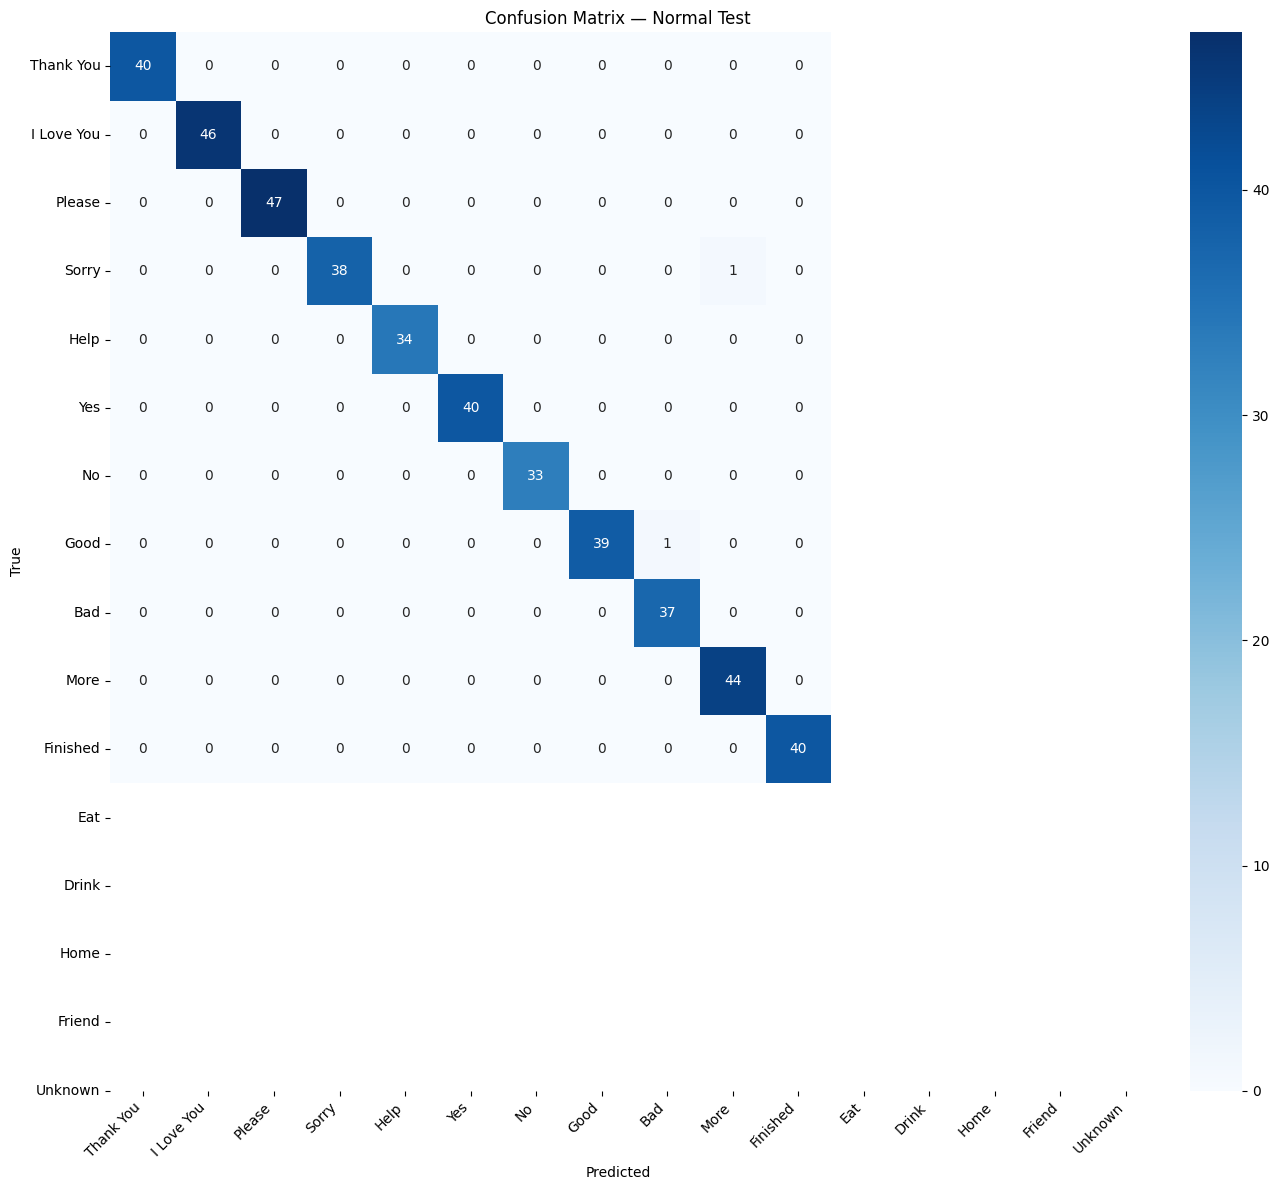

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from time import time
from sklearn.metrics import accuracy_score, recall_score, f1_score, confusion_matrix, mean_squared_error
import numpy as np
from time import time
from sklearn.metrics import accuracy_score, recall_score, f1_score, confusion_matrix, mean_squared_error
import numpy as np

y_pred = np.argmax(model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)

# Latency
times_normal = []
for x in X_test:
    t0 = time()
    model(x.reshape(1, -1))
    times_normal.append((time() - t0) * 1000)

acc = accuracy_score(y_true, y_pred)
rec = recall_score(y_true, y_pred, average='macro')
f1  = f1_score(y_true, y_pred, average='macro')
mse = mean_squared_error(y_true, y_pred)

print("=== NORMAL INPUT TEST ===")
print(f"Accuracy : {acc:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1       : {f1:.4f}")
print(f"MSE      : {mse:.4f}")
print(f"Latency  — Avg: {np.mean(times_normal):.3f} ms | Min: {np.min(times_normal):.3f} ms | Max: {np.max(times_normal):.3f} ms | p95: {np.percentile(times_normal, 95):.3f} ms")

# Confusion Matrix
PHRASE_CLASSES = [
    "Thank You", "I Love You", "Please", "Sorry", "Help",
    "Yes", "No", "Good", "Bad", "More",
    "Finished", "Eat", "Drink", "Home", "Friend", "Unknown"
]

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=PHRASE_CLASSES,
            yticklabels=PHRASE_CLASSES)
plt.title("Confusion Matrix — Normal Test")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# EDGE CASE 1 — Incomplete Landmark Input
# Simulates one hand partially outside frame / detection failure
# Zeros out 20% of the 128 features

def occlude_features(X, percent=0.2):
    X_mod    = X.copy()
    n_feat   = X.shape[1]
    n_remove = int(n_feat * percent)
    for i in range(len(X_mod)):
        idx = np.random.choice(n_feat, n_remove, replace=False)
        X_mod[i, idx] = 0
    return X_mod

X_test_occ = occlude_features(X_test, 0.2)

times_occ = []
for x in X_test_occ:
    t0 = time()
    model(x.reshape(1, -1))
    times_occ.append((time() - t0) * 1000)

y_pred_occ = np.argmax(model.predict(X_test_occ), axis=1)

print("=== EDGE CASE 1 — Incomplete Landmark Input ===")
print(f"Accuracy : {accuracy_score(y_true, y_pred_occ):.4f}")
print(f"Recall   : {recall_score(y_true, y_pred_occ, average='macro'):.4f}")
print(f"F1       : {f1_score(y_true, y_pred_occ, average='macro'):.4f}")
print(f"Latency  — Avg: {np.mean(times_occ):.3f} ms | Min: {np.min(times_occ):.3f} ms | Max: {np.max(times_occ):.3f} ms | p95: {np.percentile(times_occ, 95):.3f} ms")


In [ ]:
# EDGE CASE 2 — Noisy Landmarks
# Simulates shaky hands / tracking jitter across both hands

def add_noise(X, scale=0.02):
    return X + np.random.normal(0, scale, X.shape)

X_test_noise = add_noise(X_test, 0.02)

times_noise = []
for x in X_test_noise:
    t0 = time()
    model(x.reshape(1, -1))
    times_noise.append((time() - t0) * 1000)

y_pred_noise = np.argmax(model.predict(X_test_noise), axis=1)

print("=== EDGE CASE 2 — Landmark Noise Stability ===")
print(f"Accuracy : {accuracy_score(y_true, y_pred_noise):.4f}")
print(f"Recall   : {recall_score(y_true, y_pred_noise, average='macro'):.4f}")
print(f"F1       : {f1_score(y_true, y_pred_noise, average='macro'):.4f}")
print(f"Latency  — Avg: {np.mean(times_noise):.3f} ms | Min: {np.min(times_noise):.3f} ms | Max: {np.max(times_noise):.3f} ms | p95: {np.percentile(times_noise, 95):.3f} ms")


In [ ]:
# EDGE CASE 3 — Latency Comparison Table
print("=== EDGE CASE 3 — Latency Summary ===")
print(f"{'Test':<30} {'Avg (ms)':>10} {'Min (ms)':>10} {'Max (ms)':>10} {'p95 (ms)':>10}")
print("-" * 65)
for label, times in [
    ("Normal Input",        times_normal),
    ("Incomplete Landmark", times_occ),
    ("Landmark Noise",      times_noise),
]:
    t = np.array(times)
    print(f"{label:<30} {np.mean(t):>10.3f} {np.min(t):>10.3f} {np.max(t):>10.3f} {np.percentile(t,95):>10.3f}")


# Model Export

In [8]:
model.export("phrase_saved_model")
print("SavedModel export complete!")


INFO:tensorflow:Assets written to: phrase_saved_model/assets


INFO:tensorflow:Assets written to: phrase_saved_model/assets


Saved artifact at 'phrase_saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 16), dtype=tf.float32, name=None)
Captures:
  130822376668048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130822159678928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130822159676816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130822159677776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130822159679120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130822159678736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130822159676048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130822159677392: TensorSpec(shape=(), dtype=tf.resource, name=None)
SavedModel export complete!


In [ ]:
# Convert to TFJS (run in Google Colab if needed)
# !tensorflowjs_converter --input_format=tf_saved_model --output_format=tfjs_graph_model phrase_saved_model phrase_tfjs_model


In [ ]:
import tensorflow as tf

converter = tf.lite.TFLiteConverter.from_saved_model("phrase_saved_model")
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

with open("phrase_model.tflite", "wb") as f:
    f.write(tflite_model)

print("TFLite model saved!")


# Edge Case Testing — Live Camera (Two Hands)

Same structure as the letter model tests. Each test streams the camera inline.

### Controls
| Key | Action |
|-----|--------|
| 💾 Save Frame | Log current frame result |
| ⏹ Quit | Stop test and print summary |

> Run the **Shared Setup** cell first, then run any test independently.


In [ ]:
import cv2
import mediapipe as mp
import numpy as np
import csv
import os
import threading
import ipywidgets as widgets
from IPython.display import display
from time import time
from datetime import datetime
import tensorflow as tf

PHRASE_CLASSES = [
    "Thank You", "I Love You", "Please", "Sorry", "Help",
    "Yes", "No", "Good", "Bad", "More",
    "Finished", "Eat", "Drink", "Home", "Friend",
    "Unknown"
]
CONFIDENCE_THRESHOLD = 0.85
CENTER_BY_WRIST      = True

# Load model
model_loaded = tf.saved_model.load("phrase_saved_model")
infer        = model_loaded.signatures["serving_default"]
input_key    = list(infer.structured_input_signature[1].keys())[0]
print(f"Model loaded. Input key: {input_key}")

mp_hands = mp.solutions.hands
mp_draw  = mp.solutions.drawing_utils

def extract_two_hand_keypoints_live(result):
    left_pts  = np.zeros(64)
    right_pts = np.zeros(64)
    if result.multi_hand_landmarks:
        for lm, hd in zip(result.multi_hand_landmarks, result.multi_handedness):
            label = hd.classification[0].label
            pts   = np.array([[p.x, p.y, p.z] for p in lm.landmark])
            if CENTER_BY_WRIST:
                pts -= pts[0]
            pts_flat = np.append(pts.flatten(), 0 if label == "Left" else 1)
            if label == "Left":
                left_pts  = pts_flat
            else:
                right_pts = pts_flat
    return np.concatenate([left_pts, right_pts])

def extract_keypoints_two_hands(frame, hands_model):
    rgb    = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    result = hands_model.process(rgb)
    hands_found = 0
    if result.multi_hand_landmarks:
        hands_found = len(result.multi_hand_landmarks)
        for lm in result.multi_hand_landmarks:
            mp_draw.draw_landmarks(frame, lm, mp_hands.HAND_CONNECTIONS)
    kp = extract_two_hand_keypoints_live(result)
    return kp, frame, hands_found

def run_inference(keypoints):
    x      = tf.convert_to_tensor(keypoints.reshape(1, -1), dtype=tf.float32)
    t0     = time()
    out    = infer(**{input_key: x})
    probs  = list(out.values())[0].numpy()[0]
    lat_ms = (time() - t0) * 1000
    idx        = int(np.argmax(probs))
    confidence = float(probs[idx])
    label      = PHRASE_CLASSES[idx] if confidence >= CONFIDENCE_THRESHOLD else "Unknown"
    return label, confidence, lat_ms

def save_csv(log, filename):
    if not log:
        return
    with open(filename, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=log[0].keys())
        writer.writeheader()
        writer.writerows(log)
    print(f"  Saved → {filename}")

def print_summary(log, test_name):
    if not log:
        print("  No frames recorded.")
        return
    latencies = [r["latency_ms"] for r in log]
    valid_lat = [l for l in latencies if l > 0]
    unknown   = sum(1 for r in log if r["predicted_label"] in ("Unknown", "N/A — no hands", "—"))
    print(f"\n{'='*55}")
    print(f"  {test_name} — Summary")
    print(f"{'='*55}")
    print(f"  Frames recorded    : {len(log)}")
    print(f"  Unknown/low conf   : {unknown} / {len(log)}")
    if valid_lat:
        print(f"  --- Latency (ms) ---")
        print(f"  Avg : {np.mean(valid_lat):.3f}")
        print(f"  Min : {np.min(valid_lat):.3f}")
        print(f"  Max : {np.max(valid_lat):.3f}")
        print(f"  p95 : {np.percentile(valid_lat, 95):.3f}")
    print(f"{'='*55}\n")

def draw_hud(frame, lines, colors):
    for i, (text, color) in enumerate(zip(lines, colors)):
        cv2.putText(frame, text, (10, 30 + i*30),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

def encode_frame(frame):
    _, buf = cv2.imencode(".jpg", frame, [cv2.IMWRITE_JPEG_QUALITY, 80])
    return bytes(buf)

print("Shared setup ready. ✓")


---
## Test 1 — Normal Input
**What it tests:** Full two-hand pipeline with a phrase from the dataset.  
**Expected:** Correct phrase predicted, confidence ≥ 85 %, low latency.  
**Controls:** Show a phrase sign · **[Save Frame]** to log · **[Quit]** to stop.


In [ ]:
TEST_NAME = "Test 1 — Normal Input"
LOG_FILE  = "phrase_test1_normal.csv"
log       = []
_running  = [True]

img_out    = widgets.Image(format="jpeg", width=640, height=480)
status_out = widgets.Output()
btn_save   = widgets.Button(description="💾 Save Frame", button_style="success")
btn_quit   = widgets.Button(description="⏹ Quit",        button_style="danger")

display(widgets.VBox([
    widgets.HTML(f"<h3>{TEST_NAME}</h3>"),
    img_out,
    widgets.HBox([btn_save, btn_quit]),
    status_out
]))

def on_quit(b):
    _running[0] = False
btn_quit.on_click(on_quit)

_last = {"label": "—", "conf": 0.0, "lat_ms": 0.0, "total_ms": 0.0, "hands": 0}

def on_save(b):
    entry = {
        "timestamp":       datetime.now().isoformat(),
        "test":            TEST_NAME,
        "hands_detected":  _last["hands"],
        "predicted_label": _last["label"],
        "confidence":      round(_last["conf"], 4),
        "latency_ms":      round(_last["lat_ms"], 3),
        "total_frame_ms":  round(_last["total_ms"], 3),
    }
    log.append(entry)
    with status_out:
        print(f"  Saved: {_last['label']} ({_last['conf']*100:.1f}%) — {_last['lat_ms']:.2f} ms  [{_last['hands']} hand(s)]")
btn_save.on_click(on_save)

def camera_loop():
    hands_model = mp_hands.Hands(static_image_mode=False, max_num_hands=2,
                                 min_detection_confidence=0.7, min_tracking_confidence=0.7)
    cap = cv2.VideoCapture(0)
    while _running[0]:
        ret, frame = cap.read()
        if not ret:
            continue
        frame = cv2.flip(frame, 1)
        t0    = time()

        kp, frame, hands_found = extract_keypoints_two_hands(frame, hands_model)
        label, conf, lat_ms    = "—", 0.0, 0.0

        if hands_found > 0:
            label, conf, lat_ms = run_inference(kp)

        total_ms = (time() - t0) * 1000
        _last.update({"label": label, "conf": conf, "lat_ms": lat_ms,
                      "total_ms": total_ms, "hands": hands_found})

        color = (0,255,0) if conf >= CONFIDENCE_THRESHOLD else (0,165,255)
        draw_hud(frame,
            [f"Pred  : {label}", f"Conf  : {conf*100:.1f}%",
             f"Hands : {hands_found}", f"Lat   : {lat_ms:.1f} ms",
             f"Total : {total_ms:.1f} ms", "Click [Save Frame] or [Quit]"],
            [color, color, (255,255,0), (255,255,255), (200,200,200), (180,180,180)])

        img_out.value = encode_frame(frame)

    cap.release()
    hands_model.close()
    if log:
        save_csv(log, LOG_FILE)
    print_summary(log, TEST_NAME)

threading.Thread(target=camera_loop, daemon=True).start()


---
## Test 2 — No Input (Empty Frame)
**What it tests:** Pipeline behaviour when no hands are in frame.  
**Expected:** Model is never called, no crash, graceful handling.  
**Controls:** Keep hands OUT of frame · **[Save Frame]** to log · **[Quit]** to stop.


In [ ]:
TEST_NAME = "Test 2 — No Input"
LOG_FILE  = "phrase_test2_no_input.csv"
log       = []
_running  = [True]

img_out    = widgets.Image(format="jpeg", width=640, height=480)
status_out = widgets.Output()
btn_save   = widgets.Button(description="💾 Save Frame", button_style="success")
btn_quit   = widgets.Button(description="⏹ Quit",        button_style="danger")

display(widgets.VBox([
    widgets.HTML(f"<h3>{TEST_NAME}</h3>"),
    img_out,
    widgets.HBox([btn_save, btn_quit]),
    status_out
]))

def on_quit(b):
    _running[0] = False
btn_quit.on_click(on_quit)

_last = {"hands": 0, "total_ms": 0.0}

def on_save(b):
    entry = {
        "timestamp":       datetime.now().isoformat(),
        "test":            TEST_NAME,
        "hands_detected":  _last["hands"],
        "predicted_label": "N/A — no hands" if _last["hands"] == 0 else "Hands detected!",
        "confidence":      0.0,
        "latency_ms":      0.0,
        "total_frame_ms":  round(_last["total_ms"], 3),
    }
    log.append(entry)
    with status_out:
        status = f"No hands ({_last['total_ms']:.2f} ms)" if _last["hands"] == 0 else f"⚠ {_last['hands']} hand(s) detected!"
        print(f"  Saved: {status}")
btn_save.on_click(on_save)

def camera_loop():
    hands_model = mp_hands.Hands(static_image_mode=False, max_num_hands=2,
                                 min_detection_confidence=0.7, min_tracking_confidence=0.7)
    cap = cv2.VideoCapture(0)
    while _running[0]:
        ret, frame = cap.read()
        if not ret:
            continue
        frame    = cv2.flip(frame, 1)
        t0       = time()
        _, frame, hands_found = extract_keypoints_two_hands(frame, hands_model)
        total_ms = (time() - t0) * 1000
        _last.update({"hands": hands_found, "total_ms": total_ms})

        status = f"⚠ {hands_found} hand(s) detected!" if hands_found > 0 else "No hands detected"
        color  = (0,0,255) if hands_found > 0 else (0,200,255)
        draw_hud(frame,
            [status, f"Total: {total_ms:.1f} ms", "Click [Save Frame] or [Quit]"],
            [color, (200,200,200), (180,180,180)])

        img_out.value = encode_frame(frame)

    cap.release()
    hands_model.close()
    if log:
        save_csv(log, LOG_FILE)
    print_summary(log, TEST_NAME)

threading.Thread(target=camera_loop, daemon=True).start()


---
## Test 3 — Unknown / Out-of-Distribution Input
**What it tests:** Model behaviour on signs NOT in the dataset.  
**Expected:** Confidence < 85 % → flagged "Unknown". High confidence on wrong label = lower threshold needed.  
**Controls:** Show signs NOT in dataset · **[Save Frame]** to log · **[Quit]** to stop.


In [ ]:
TEST_NAME = "Test 3 — Unknown Input"
LOG_FILE  = "phrase_test3_unknown.csv"
log       = []
_running  = [True]

img_out    = widgets.Image(format="jpeg", width=640, height=480)
status_out = widgets.Output()
btn_save   = widgets.Button(description="💾 Save Frame", button_style="success")
btn_quit   = widgets.Button(description="⏹ Quit",        button_style="danger")

display(widgets.VBox([
    widgets.HTML(f"<h3>{TEST_NAME}</h3>"),
    img_out,
    widgets.HBox([btn_save, btn_quit]),
    status_out
]))

def on_quit(b):
    _running[0] = False
btn_quit.on_click(on_quit)

_last = {"raw": "—", "label": "—", "conf": 0.0,
         "lat_ms": 0.0, "total_ms": 0.0, "hands": 0}

def on_save(b):
    entry = {
        "timestamp":           datetime.now().isoformat(),
        "test":                TEST_NAME,
        "hands_detected":      _last["hands"],
        "raw_predicted_label": _last["raw"],
        "predicted_label":     _last["label"],
        "confidence":          round(_last["conf"], 4),
        "confidently_wrong":   _last["hands"] > 0 and _last["label"] != "Unknown",
        "latency_ms":          round(_last["lat_ms"], 3),
        "total_frame_ms":      round(_last["total_ms"], 3),
    }
    log.append(entry)
    with status_out:
        flag = "⚠ CONFIDENTLY WRONG" if entry["confidently_wrong"] else "✓ Unknown"
        print(f"  Saved: raw={_last['raw']} → {_last['label']} ({_last['conf']*100:.1f}%) {flag} — {_last['lat_ms']:.2f} ms")
btn_save.on_click(on_save)

def camera_loop():
    hands_model = mp_hands.Hands(static_image_mode=False, max_num_hands=2,
                                 min_detection_confidence=0.7, min_tracking_confidence=0.7)
    cap = cv2.VideoCapture(0)
    while _running[0]:
        ret, frame = cap.read()
        if not ret:
            continue
        frame = cv2.flip(frame, 1)
        t0    = time()

        kp, frame, hands_found = extract_keypoints_two_hands(frame, hands_model)
        raw_label, label, conf, lat_ms = "—", "—", 0.0, 0.0

        if hands_found > 0:
            x      = tf.convert_to_tensor(kp.reshape(1,-1), dtype=tf.float32)
            ti     = time()
            out    = infer(**{input_key: x})
            probs  = list(out.values())[0].numpy()[0]
            lat_ms = (time() - ti) * 1000
            idx       = int(np.argmax(probs))
            conf      = float(probs[idx])
            raw_label = PHRASE_CLASSES[idx]
            label     = raw_label if conf >= CONFIDENCE_THRESHOLD else "Unknown"

        total_ms = (time() - t0) * 1000
        _last.update({"raw": raw_label, "label": label, "conf": conf,
                      "lat_ms": lat_ms, "total_ms": total_ms, "hands": hands_found})

        is_safe = (label == "Unknown" or hands_found == 0)
        color   = (0,255,0) if is_safe else (0,0,255)
        draw_hud(frame,
            [f"Raw   : {raw_label}", f"Result: {label}",
             f"Conf  : {conf*100:.1f}%", f"Hands : {hands_found}",
             f"Lat   : {lat_ms:.1f} ms", f"Total : {total_ms:.1f} ms",
             "Click [Save Frame] or [Quit]"],
            [(200,200,200), color, color, (255,255,0),
             (255,255,255), (200,200,200), (180,180,180)])

        img_out.value = encode_frame(frame)

    cap.release()
    hands_model.close()
    if log:
        save_csv(log, LOG_FILE)
    confidently_wrong = [r for r in log if r.get("confidently_wrong")]
    print_summary(log, TEST_NAME)
    if confidently_wrong:
        print(f"  ⚠  CONFIDENTLY WRONG frames : {len(confidently_wrong)}")
        print(f"     Lower CONFIDENCE_THRESHOLD or add more Unknown samples.")
    elif log:
        print(f"  ✓  All unknown gestures correctly flagged.")

threading.Thread(target=camera_loop, daemon=True).start()


---
## Combined Results Summary
Run after completing all three tests.

In [ ]:
import csv
import numpy as np
import os

files = {
    "Test 1 — Normal Input":  "phrase_test1_normal.csv",
    "Test 2 — No Input":      "phrase_test2_no_input.csv",
    "Test 3 — Unknown Input": "phrase_test3_unknown.csv",
}

print(f"{'Test':<28} {'Frames':>7} {'Detected':>9} {'Unknown':>9} {'Avg ms':>8} {'Max ms':>8} {'p95 ms':>8}")
print("-" * 82)

for name, path in files.items():
    if not os.path.exists(path):
        print(f"{name:<28}  — file not found, skip")
        continue
    with open(path) as f:
        rows = list(csv.DictReader(f))
    if not rows:
        print(f"{name:<28}  — empty log")
        continue

    latencies = [float(r["latency_ms"]) for r in rows]
    detected  = sum(1 for r in rows if int(r.get("hands_detected", 0)) > 0)
    unknown   = sum(1 for r in rows if r["predicted_label"] in ("Unknown", "N/A — no hands", "—"))
    valid_lat = [l for l in latencies if l > 0]
    avg = np.mean(valid_lat) if valid_lat else 0
    mx  = np.max(valid_lat)  if valid_lat else 0
    p95 = np.percentile(valid_lat, 95) if valid_lat else 0

    print(f"{name:<28} {len(rows):>7} {detected:>9} {unknown:>9} {avg:>8.2f} {mx:>8.2f} {p95:>8.2f}")

print("-" * 82)
print("Latency = model inference only (ms). Total frame time includes MediaPipe.")
